In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load data
df=pd.read_csv("weather_data_500_rows.csv")

In [ ]:
# Load and Inspect Data
print("Fisrt 5 Rows of Weathar.")
print(df.head())
print(df.tail())

Fisrt 5 Rows of Weathar.
         Date  Temperature_C  Humidity_Pct  Precipitation_mm
0  2023-01-01           16.7          77.9               0.0
1  2023-01-02           15.0          89.1               0.0
2  2023-01-03           17.6          54.0               2.5
3  2023-01-04           20.4          71.3               3.1
4  2023-01-05           15.3          63.2               0.0
           Date  Temperature_C  Humidity_Pct  Precipitation_mm
495  2024-05-10           25.9          58.5               3.3
496  2024-05-11           21.1          83.1               1.8
497  2024-05-12           23.5          69.6               2.9
498  2024-05-13           21.3          59.3               0.0
499  2024-05-14           19.6          72.0               0.0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              500 non-null    object 
 1   Temperature_C     490 non-null    float64
 2   Humidity_Pct      490 non-null    float64
 3   Precipitation_mm  500 non-null    float64
dtypes: float64(3), object(1)
memory usage: 15.8+ KB
None


In [ ]:
# Data Cleaning

print("Missing values Before Cleaning")
print(df.isnull().sum())
df['Temperature_C'] = df['Temperature_C'].interpolate(method='linear')
df['Humidity_Pct'] = df['Humidity_Pct'].fillna(df['Humidity_Pct'].mean())
df['Precipitation_mm'] = df['Precipitation_mm'].fillna(0.0)

Missing values Before Cleaning
Date                 0
Temperature_C       10
Humidity_Pct        10
Precipitation_mm     0
dtype: int64


In [ ]:
# Convert data

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
print("Missing value After Cleaning")
print(df.isnull().sum())

Missing value After Cleaning
Date                0
Temperature_C       0
Humidity_Pct        0
Precipitation_mm    0
Year                0
Month               0
Month_Name          0
dtype: int64


In [ ]:
# Descriptive Statistics with NumPy

temp_np = df['Temperature_C'].to_numpy()
hum_np = df['Humidity_Pct'].to_numpy()
prec_np = df['Precipitation_mm'].to_numpy()

stats_summary = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev'],
    'Temperature (°C)': [np.mean(temp_np), np.median(temp_np), np.std(temp_np)],
    'Humidity (%)': [np.mean(hum_np), np.median(hum_np), np.std(hum_np)],
    'Precipitation (mm)': [np.mean(prec_np), np.median(prec_np), np.std(prec_np)]
})

print("DESCRIPTIVE STATISTICS")
print(stats_summary.round(2).to_string(index=False))


DESCRIPTIVE STATISTICS
 Metric  Temperature (°C)  Humidity (%)  Precipitation (mm)
   Mean             17.37         68.31                2.26
 Median             19.10         67.95                1.80
Std Dev              8.78         12.02                2.82


In [ ]:
# Monthly and Seasonal Analysis (Using Pandas Group By)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Group by Month
print("--- MONTHLY AVERAGES ---")
print(df.groupby('Month_Name')[['Temperature_C', 'Humidity_Pct', 'Precipitation_mm']].mean().round(2))

# Group by Season
print("\n--- SEASONAL AVERAGES ---")
print(df.groupby('Season')[['Temperature_C', 'Humidity_Pct', 'Precipitation_mm']].mean().round(2))

--- MONTHLY AVERAGES ---
            Temperature_C  Humidity_Pct  Precipitation_mm
Month_Name                                               
Apr                 26.34         61.50              2.20
Aug                  6.67         76.14              1.90
Dec                 11.81         73.79              2.33
Feb                 23.56         63.68              2.43
Jan                 18.15         68.90              2.67
Jul                 12.36         70.70              1.24
Jun                 18.96         66.04              3.37
Mar                 26.06         60.80              2.04
May                 23.68         62.64              2.32
Nov                  7.37         76.61              1.92
Oct                  3.75         79.33              2.12
Sep                  3.15         79.85              2.38

--- SEASONAL AVERAGES ---
        Temperature_C  Humidity_Pct  Precipitation_mm
Season                                               
Autumn           4.75       

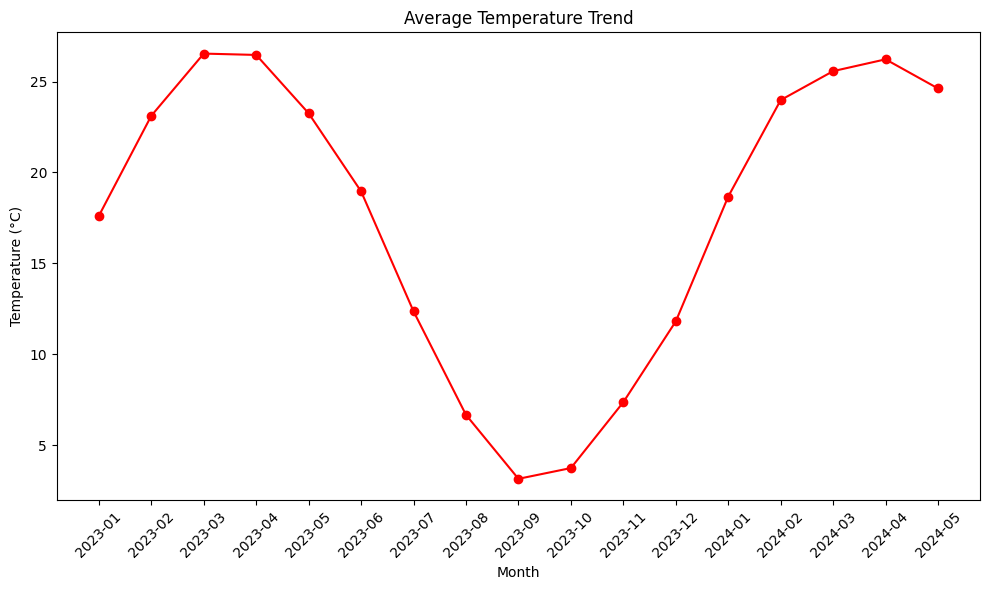

In [ ]:
# Line Plot: Temperature Trend

monthly_temp = df.groupby(
    df['Date'].dt.to_period('M')
)['Temperature_C'].mean()
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_temp.index.astype(str),
    monthly_temp.values,
    marker='o',
    color='red'
)
plt.title('Average Temperature Trend')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

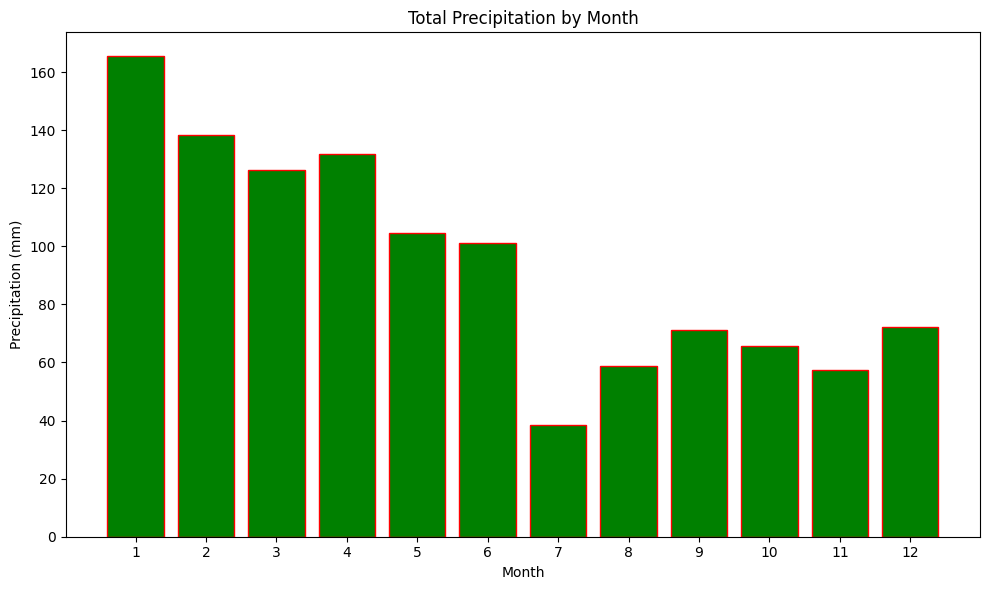

In [ ]:
# Bar Plot: Precipitation by Month

monthly_precip = df.groupby('Month')['Precipitation_mm'].sum()
plt.figure(figsize=(10, 6))
plt.bar(
    monthly_precip.index,
    monthly_precip.values,
    color='green',
    edgecolor='red'
)
plt.title('Total Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

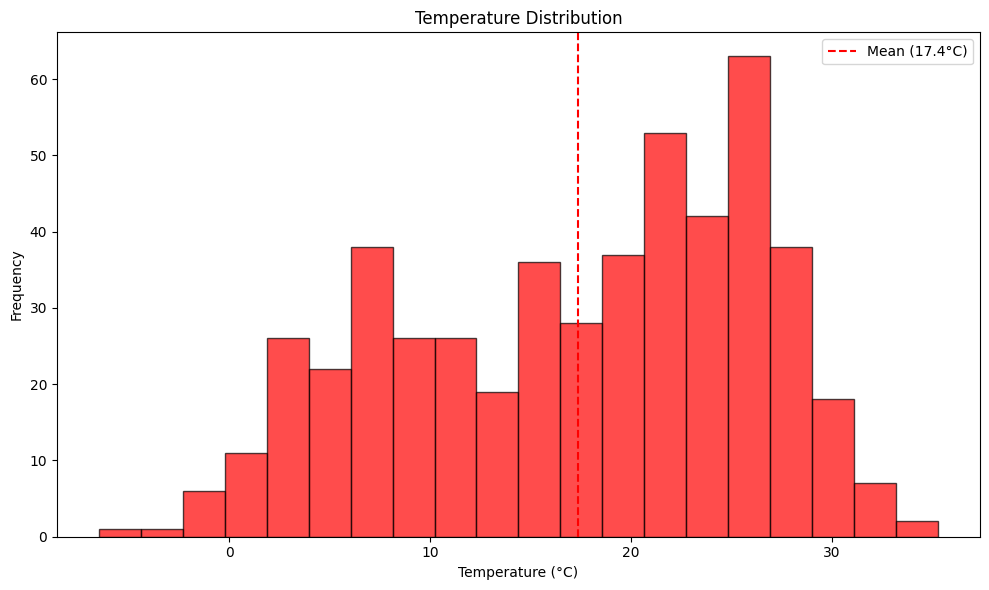

In [ ]:
# Histogram: Temperature Distribution

plt.figure(figsize=(10, 6))
plt.hist(df['Temperature_C'], bins=20, color='red',
         edgecolor='black', alpha=0.7)
plt.axvline(np.mean(temp_np), color='red', linestyle='--',
            label=f'Mean ({np.mean(temp_np):.1f}°C)')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# # # Print all clm
# # print(df.columns)
df.info()
# df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              500 non-null    datetime64[ns]
 1   Temperature_C     500 non-null    float64       
 2   Humidity_Pct      500 non-null    float64       
 3   Precipitation_mm  500 non-null    float64       
 4   Year              500 non-null    int32         
 5   Month             500 non-null    int32         
 6   Month_Name        500 non-null    object        
 7   Season            500 non-null    object        
dtypes: datetime64[ns](1), float64(3), int32(2), object(2)
memory usage: 27.5+ KB


In [ ]:
monthly_temp = df.groupby("Month_Name")["Temperature_C"].mean()
print(monthly_temp)

Month_Name
Apr    26.344167
Aug     6.669355
Dec    11.812903
Feb    23.558772
Jan    18.146774
Jul    12.361290
Jun    18.960000
Mar    26.056452
May    23.680000
Nov     7.370000
Oct     3.745161
Sep     3.153333
Name: Temperature_C, dtype: float64


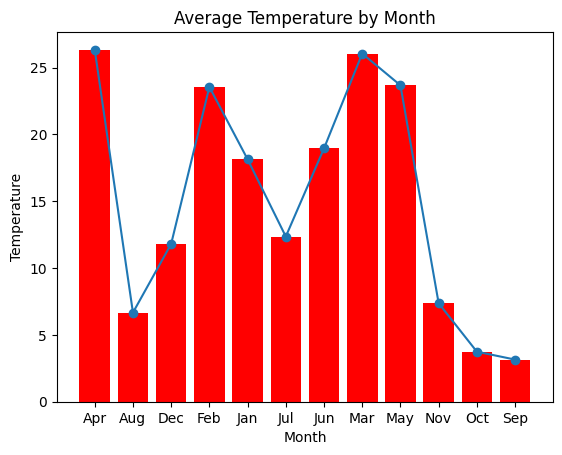

In [ ]:
plt.bar(monthly_temp.index, monthly_temp.values, color="red")
monthly_temp.plot(kind="line", marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [ ]:
# print(df.columns)
print(df.head(5))

Index(['Date', 'Temperature_C', 'Humidity_Pct', 'Precipitation_mm', 'Year',
       'Month', 'Month_Name', 'Season'],
      dtype='object')
        Date  Temperature_C  Humidity_Pct  Precipitation_mm  Year  Month  \
0 2023-01-01           16.7          77.9               0.0  2023      1   
1 2023-01-02           15.0          89.1               0.0  2023      1   
2 2023-01-03           17.6          54.0               2.5  2023      1   
3 2023-01-04           20.4          71.3               3.1  2023      1   
4 2023-01-05           15.3          63.2               0.0  2023      1   

  Month_Name  Season  
0        Jan  Winter  
1        Jan  Winter  
2        Jan  Winter  
3        Jan  Winter  
4        Jan  Winter  


In [ ]:
print(df.info())
# print(df.dtype())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              500 non-null    datetime64[ns]
 1   Temperature_C     500 non-null    float64       
 2   Humidity_Pct      500 non-null    float64       
 3   Precipitation_mm  500 non-null    float64       
 4   Year              500 non-null    int32         
 5   Month             500 non-null    int32         
 6   Month_Name        500 non-null    object        
 7   Season            500 non-null    object        
dtypes: datetime64[ns](1), float64(3), int32(2), object(2)
memory usage: 27.5+ KB
None


In [ ]:
print(df.columns)

Index(['Date', 'Temperature_C', 'Humidity_Pct', 'Precipitation_mm', 'Year',
       'Month', 'Month_Name', 'Season'],
      dtype='object')


In [ ]:
print(df.info)

<bound method DataFrame.info of           Date  Temperature_C  Humidity_Pct  Precipitation_mm  Year  Month  \
0   2023-01-01           16.7          77.9               0.0  2023      1   
1   2023-01-02           15.0          89.1               0.0  2023      1   
2   2023-01-03           17.6          54.0               2.5  2023      1   
3   2023-01-04           20.4          71.3               3.1  2023      1   
4   2023-01-05           15.3          63.2               0.0  2023      1   
..         ...            ...           ...               ...   ...    ...   
495 2024-05-10           25.9          58.5               3.3  2024      5   
496 2024-05-11           21.1          83.1               1.8  2024      5   
497 2024-05-12           23.5          69.6               2.9  2024      5   
498 2024-05-13           21.3          59.3               0.0  2024      5   
499 2024-05-14           19.6          72.0               0.0  2024      5   

    Month_Name  Season  
0     

In [ ]:
print(df.dtypes)

Date                datetime64[ns]
Temperature_C              float64
Humidity_Pct               float64
Precipitation_mm           float64
Year                         int32
Month                        int32
Month_Name                  object
Season                      object
dtype: object


In [ ]:
# df.groupby("Season")("Temperature_C").max()
df.groupby("Season")["Temperature_C"].max()

,Temperature_C
Season,
Autumn,13.5
Spring,35.3
Summer,25.7
Winter,31.0
